# Standard Gaussian Naive Bayes - Cancer Risk Dataset

This notebook trains a standard (non-private) Gaussian Naive Bayes classifier on the Cancer Risk dataset to establish baseline performance.

## 1. Import Libraries

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    f1_score,
    precision_score,
    recall_score
)
import pickle
import json
import warnings
warnings.filterwarnings('ignore')

# Shared metric collector (repository root): logs training accuracy,
# balanced accuracy and AUROC alongside the metrics already tracked below.
import os as _os
import sys as _sys
_REPO_ROOT = _os.path.abspath(_os.path.join('..', '..'))
if _REPO_ROOT not in _sys.path:
    _sys.path.insert(0, _REPO_ROOT)
from metrics_utils import ExtraMetrics


## 2. Load Preprocessed Data

In [2]:
with open('../data/processed_data.pkl', 'rb') as f:
    data = pickle.load(f)

X_train = data['X_train']
X_test = data['X_test']
y_train = data['y_train']
y_test = data['y_test']
feature_names = data['feature_names']

print(f"Training data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")
print(f"Number of features: {len(feature_names)}")
print(f"\nFeatures: {feature_names}")

Training data shape: (1200, 8)
Test data shape: (300, 8)
Number of features: 8

Features: ['Age', 'Gender', 'BMI', 'Smoking', 'GeneticRisk', 'PhysicalActivity', 'AlcoholIntake', 'CancerHistory']


## 3. Train Standard Gaussian NB (30 runs)

In [3]:
N_RUNS = 30

detail_accuracies = []
detail_f1s = []
detail_precisions = []
detail_recalls = []

print(f"Training Standard GNB {N_RUNS} times (deterministic - should be identical)...")
print("=" * 60)

extra = ExtraMetrics()
for run in range(N_RUNS):
    gnb_model = GaussianNB()
    _t0 = time.perf_counter()
    gnb_model.fit(X_train, y_train)
    train_time = time.perf_counter() - _t0
    # Score the non-private fit on the training partition too, so the
    # generalisation gap can be read next to the held-out metrics.
    y_train_pred = gnb_model.predict(X_train)
    y_pred = gnb_model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    extra.add(y_test, y_pred, model=gnb_model, X=X_test, train_true=y_train, train_pred=y_train_pred, train_time=train_time)
    f1 = f1_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)

    detail_accuracies.append(acc)
    detail_f1s.append(f1)
    detail_precisions.append(prec)
    detail_recalls.append(rec)

    if run == 0:
        print(f"  Run {run+1:2d}/{N_RUNS} | Acc: {acc:.4f} | F1: {f1:.4f} | Prec: {prec:.4f} | Rec: {rec:.4f}")

print(f"  ... (all {N_RUNS} runs identical)")
print("=" * 60)

Training Standard GNB 30 times (deterministic - should be identical)...
  Run  1/30 | Acc: 0.8300 | F1: 0.7358 | Prec: 0.8659 | Rec: 0.6396
  ... (all 30 runs identical)


In [4]:
# Export model for MIA
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..', '..')))
from model_exporter import export_model

export_model(gnb_model, 'output/model/std_gnb_model.pkl')

Model successfully exported to output/model/std_gnb_model.pkl


## 4. Model Evaluation

In [5]:
accuracy = float(np.mean(detail_accuracies))
f1 = float(np.mean(detail_f1s))
precision = float(np.mean(detail_precisions))
recall = float(np.mean(detail_recalls))

print("="*60)
print("STANDARD GAUSSIAN NAIVE BAYES - PERFORMANCE METRICS")
print("="*60)
print(f"Accuracy:  {accuracy:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print("="*60)

STANDARD GAUSSIAN NAIVE BAYES - PERFORMANCE METRICS
Accuracy:  0.8300
F1-Score:  0.7358
Precision: 0.8659
Recall:    0.6396


## 5. Confusion Matrix

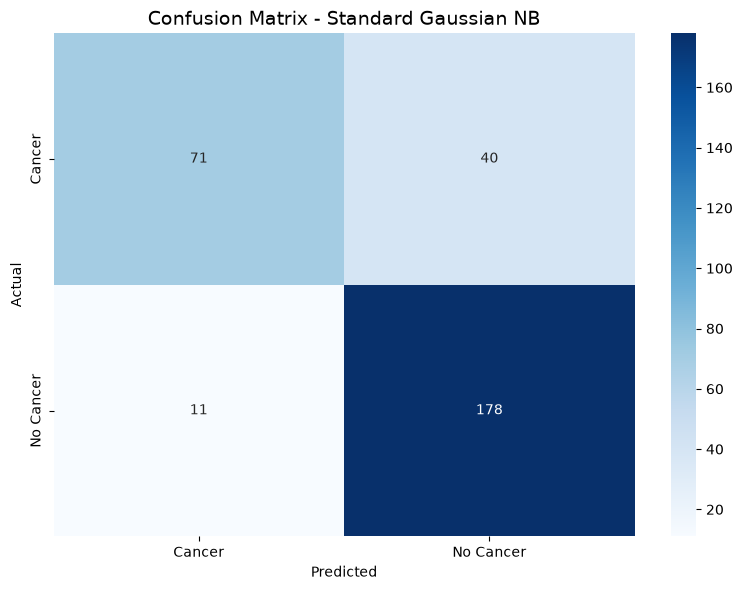

In [6]:
y_pred = gnb_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

TN = cm[0, 0]
FP = cm[0, 1]
FN = cm[1, 0]
TP = cm[1, 1]

custom_cm = np.array([[TP, FN], [FP, TN]])

plt.figure(figsize=(8, 6))
sns.heatmap(custom_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Cancer', 'No Cancer'],
            yticklabels=['Cancer', 'No Cancer'])
plt.title('Confusion Matrix - Standard Gaussian NB', fontsize=14)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## 6. Classification Report

In [7]:
print("Classification Report:")
print(classification_report(y_test, y_pred, 
                          target_names=['No Cancer', 'Cancer']))

Classification Report:
              precision    recall  f1-score   support

   No Cancer       0.82      0.94      0.87       189
      Cancer       0.87      0.64      0.74       111

    accuracy                           0.83       300
   macro avg       0.84      0.79      0.81       300
weighted avg       0.83      0.83      0.82       300



## 7. Save Baseline Results

In [8]:
import os
os.makedirs('output', exist_ok=True)

baseline_results = pd.DataFrame({
    'model': ['Standard_GNB'],
    'accuracy': [accuracy],
    'f1_score': [f1],
    'precision': [precision],
    'recall': [recall]
})

baseline_results.to_csv('output/baseline_results.csv', index=False)
print("Baseline results saved to 'output/baseline_results.csv'")

report = {
    'model_type': 'Standard Gaussian Naive Bayes',
    'dataset': 'Cancer Risk Prediction',
    'parameters': {},
    'metrics': {
        'accuracy': float(accuracy),
        'f1_score': float(f1),
        'precision': float(precision),
        'recall': float(recall)
    },
    'confusion_matrix': custom_cm.tolist()
}
report.update(extra.means())

with open('output/std_gnb_report.json', 'w') as f:
    json.dump(report, f, indent=4)

print("Detailed report saved to 'output/std_gnb_report.json'")

print("Added metrics:")
print(extra.describe())

Baseline results saved to 'output/baseline_results.csv'
Detailed report saved to 'output/std_gnb_report.json'
Added metrics:
  Train Acc:      0.8300 ± 0.0000
  Balanced Acc:   0.7907 ± 0.0000
  AUROC:          0.9098 ± 0.0000
  Train Time (s): 0.0002 ± 0.0001


## 8. Summary

In [9]:
print("\n" + "="*60)
print("BASELINE MODEL SUMMARY")
print("="*60)
print(f"Model: Standard Gaussian Naive Bayes")
print(f"Dataset: Cancer Risk Prediction ({X_train.shape[0]:,} train, {X_test.shape[0]:,} test)")
print(f"\nPerformance Metrics:")
print(f"  Accuracy:  {accuracy:.4f}")
print(f"  F1-Score:  {f1:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"\nBaseline established for DP comparison")
print("="*60)


BASELINE MODEL SUMMARY
Model: Standard Gaussian Naive Bayes
Dataset: Cancer Risk Prediction (1,200 train, 300 test)

Performance Metrics:
  Accuracy:  0.8300
  F1-Score:  0.7358
  Precision: 0.8659
  Recall:    0.6396

Baseline established for DP comparison
